In [ ]:
import torch, torchvision, pynvml
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
# Define transformations and load the dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.53MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 200kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 1.87MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.08MB/s]


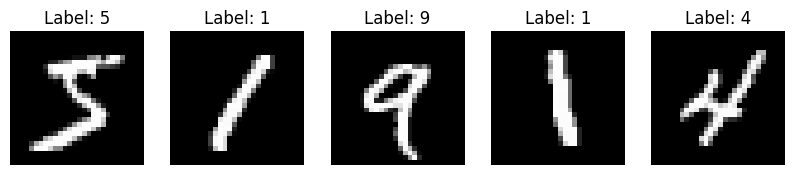

In [3]:
# Create a DataLoader without shuffling
trainloader_no_shuffle = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=False)

# Get a batch of training images
dataiter = iter(trainloader_no_shuffle)
images, labels = next(dataiter)  # Get the first batch of images

# Select specific indices of images you want to use
selected_indices = [0, 3, 4, 6, 9]  # Example indices

# Display the selected images and their labels
plt.figure(figsize=(10, 4))
for i, idx in enumerate(selected_indices):
    plt.subplot(1, len(selected_indices), i+1)
    plt.imshow(images[idx].numpy().squeeze(), cmap='gray')
    plt.title(f'Label: {labels[idx].item()}')
    plt.axis('off')
plt.show()

In [4]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)  # Flatten the image
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Instantiate the model
model = SimpleNN()


# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model
for epoch in range(1):  # Train for 1 epoch
    for images, labels in trainloader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f'Epoch {epoch + 1} completed')

print('Finished Training')

Epoch 1 completed
Finished Training


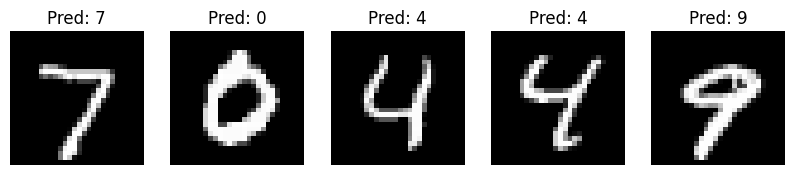

In [5]:
# Create a DataLoader without shuffling
testloader_no_shuffle = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

# Get a batch of test images
dataiter = iter(testloader_no_shuffle)
images, labels = next(dataiter)  # Get the first batch of images

# Select specific indices of images you want to use for predictions
selected_indices = [0, 3, 4, 6, 9]  # Example indices

# Predict the labels for the selected images
outputs = model(images[selected_indices])
_, predicted = torch.max(outputs, 1)

# Display the selected images and their predicted labels
plt.figure(figsize=(10, 4))
for i, idx in enumerate(selected_indices):
    plt.subplot(1, len(selected_indices), i+1)
    plt.imshow(images[idx].numpy().squeeze(), cmap='gray')
    plt.title(f'Pred: {predicted[i].item()}')
    plt.axis('off')
plt.show()